# OA Barrier Scenario 1 — Analysis
Analysis of `OA_barrier_scenario_1` across different temperatures, substrates, and ligands.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

TARGET = 'OA_barrier_scenario_1'

## 1. Load & inspect data

In [ ]:
df = pd.read_csv(r"MKM-df_OA_barriers.csv")
print(df.shape)
df.head(10)

(120, 5)


,temp_C,substrate,ligand,OA_barrier_scenario_1,OA_barrier_scenario_2
0,30,3_bromoquinoline,PCy3,7.704827,28.938457
1,30,2_chloropyridine,PCy3,4.453053,29.268424
2,30,3_chloropyridine,PCy3,10.510503,35.325873
3,30,3_bromoquinoline,PPh3,8.083937,22.379371
4,30,2_chloropyridine,PPh3,5.546570,24.253490
5,30,3_chloropyridine,PPh3,10.376785,28.560736
6,30,3_bromoquinoline,AmPhos,10.602732,28.288924
7,30,2_chloropyridine,AmPhos,7.747104,31.332999
8,30,3_chloropyridine,AmPhos,10.261574,33.479732
9,30,3_bromoquinoline,Catacxium_A,8.679677,26.758462


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   temp_C                 120 non-null    int64  
 1   substrate              120 non-null    object 
 2   ligand                 120 non-null    object 
 3   OA_barrier_scenario_1  120 non-null    float64
 4   OA_barrier_scenario_2  120 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 4.8+ KB


In [5]:
df[TARGET].describe().round(3)

count    120.000
mean      10.696
std        3.433
min        4.453
25%        8.166
50%       10.135
75%       12.533
max       19.418
Name: OA_barrier_scenario_1, dtype: float64

In [6]:
print('Temperatures (°C):', sorted(df['temp_C'].unique()))
print('Substrates:', df['substrate'].unique().tolist())
print('Ligands:   ', df['ligand'].unique().tolist())

Temperatures (°C): [np.int64(30), np.int64(50), np.int64(70), np.int64(90), np.int64(110)]
Substrates: ['3_bromoquinoline', '2_chloropyridine', '3_chloropyridine']
Ligands:    ['PCy3', 'PPh3', 'AmPhos', 'Catacxium_A', 'RuPhos', 'SPhos', 'tBu3', 'XPhos']


## 2. Overall distribution

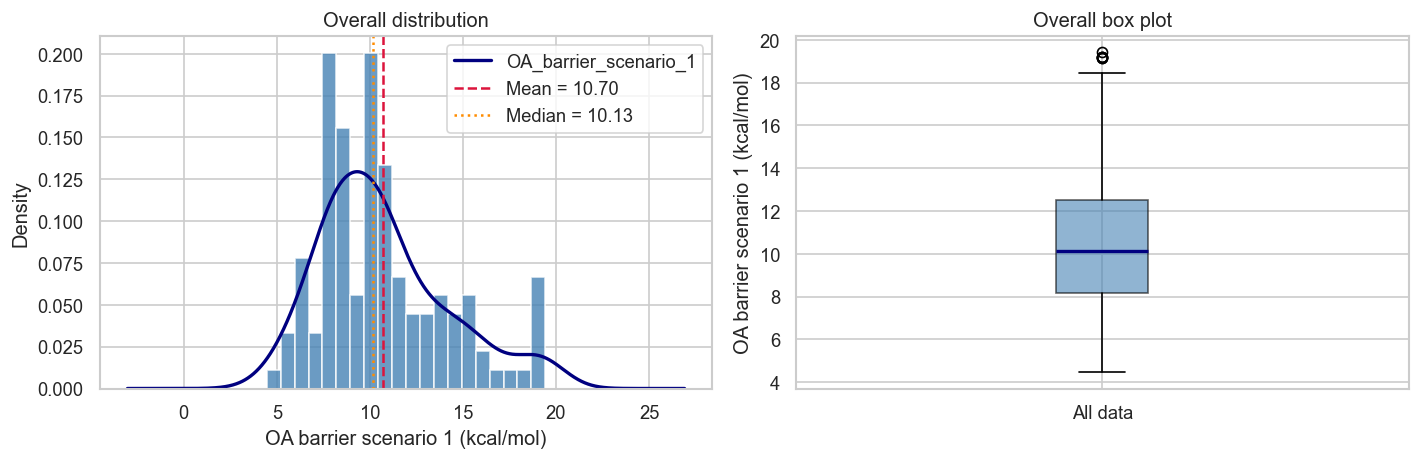

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram + KDE
axes[0].hist(df[TARGET], bins=20, color='steelblue', edgecolor='white', alpha=0.8, density=True)
df[TARGET].plot.kde(ax=axes[0], color='navy', linewidth=2)
axes[0].axvline(df[TARGET].mean(), color='crimson', linestyle='--', linewidth=1.5, label=f'Mean = {df[TARGET].mean():.2f}')
axes[0].axvline(df[TARGET].median(), color='darkorange', linestyle=':', linewidth=1.5, label=f'Median = {df[TARGET].median():.2f}')
axes[0].set_xlabel('OA barrier scenario 1 (kcal/mol)')
axes[0].set_ylabel('Density')
axes[0].set_title('Overall distribution')
axes[0].legend()

# Box plot
axes[1].boxplot(df[TARGET].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='navy', linewidth=2))
axes[1].set_ylabel('OA barrier scenario 1 (kcal/mol)')
axes[1].set_xticklabels(['All data'])
axes[1].set_title('Overall box plot')

plt.tight_layout()
plt.show()

## 3. Analysis by temperature

In [7]:
temp_stats = (
    df.groupby('temp_C')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
)
temp_stats

,mean,median,std,min,max,count
temp_C,,,,,,
30,9.848,9.778,3.196,4.453,19.206,24
50,10.220,9.814,3.291,5.387,19.190,24
70,10.646,10.168,3.397,6.180,19.175,24
90,11.118,10.192,3.546,6.197,19.161,24
110,11.647,10.525,3.703,6.216,19.418,24


C:\Users\livio\AppData\Local\Temp\ipykernel_3640\3347532249.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_temp, labels=labels, patch_artist=True,


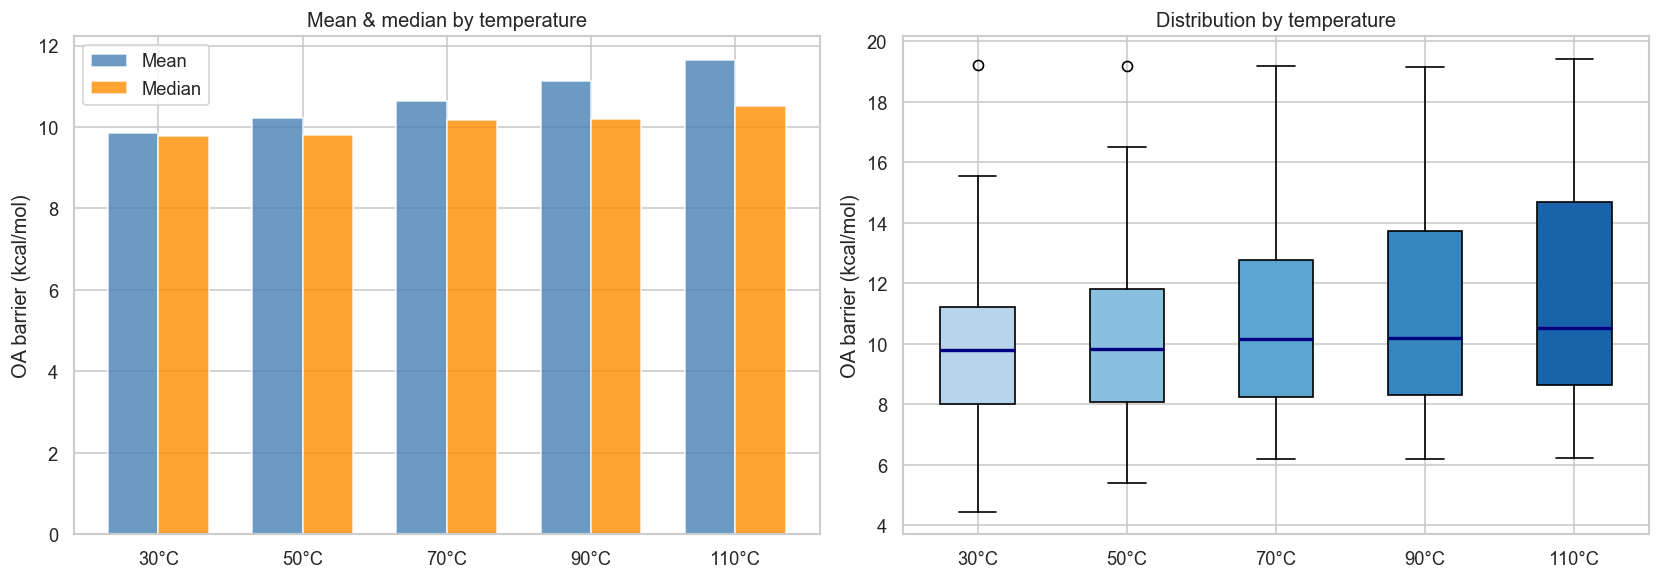

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

temps = sorted(df['temp_C'].unique())
labels = [f'{t}°C' for t in temps]

# Mean & median bar chart
x = np.arange(len(temps))
w = 0.35
axes[0].bar(x - w/2, temp_stats['mean'], width=w, label='Mean', color='steelblue', alpha=0.8)
axes[0].bar(x + w/2, temp_stats['median'], width=w, label='Median', color='darkorange', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('OA barrier (kcal/mol)')
axes[0].set_title('Mean & median by temperature')
axes[0].legend()

# Box plot by temperature
data_by_temp = [df[df['temp_C'] == t][TARGET].values for t in temps]
bp = axes[1].boxplot(data_by_temp, labels=labels, patch_artist=True,
                     medianprops=dict(color='navy', linewidth=2))
colors = plt.cm.Blues(np.linspace(0.3, 0.8, len(temps)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_ylabel('OA barrier (kcal/mol)')
axes[1].set_title('Distribution by temperature')

plt.tight_layout()
plt.show()

C:\Users\livio\AppData\Local\Temp\ipykernel_3640\2657487982.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='temp_C', y=TARGET, palette='Blues', inner='box', ax=ax)


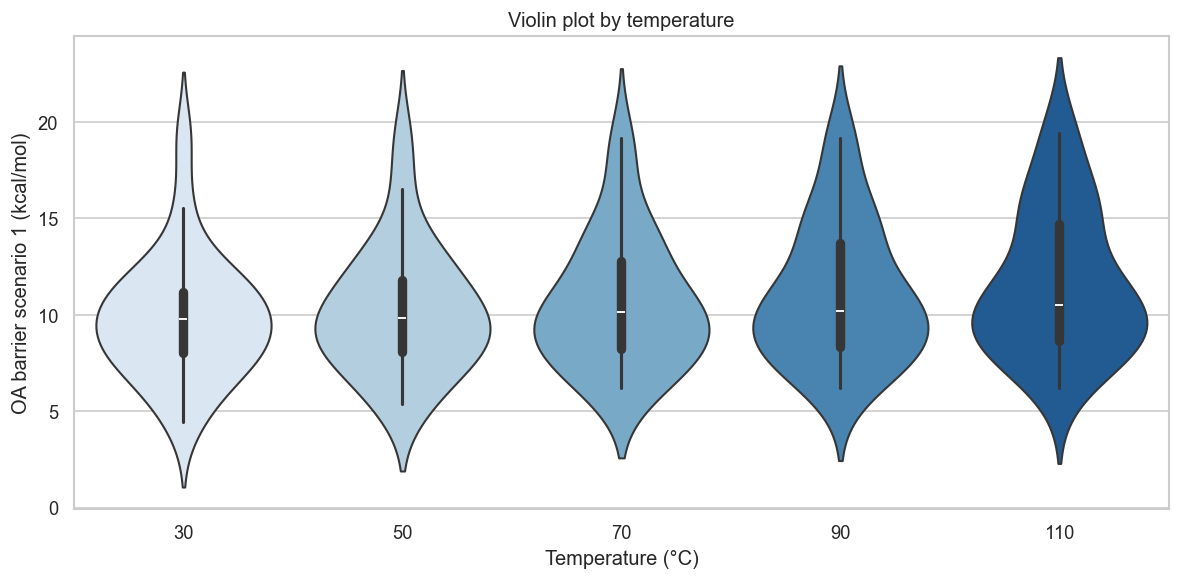

In [9]:
# Violin plot by temperature
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df, x='temp_C', y=TARGET, palette='Blues', inner='box', ax=ax)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('OA barrier scenario 1 (kcal/mol)')
ax.set_title('Violin plot by temperature')
plt.tight_layout()
plt.show()

## 4. Analysis by substrate

In [10]:
sub_stats = (
    df.groupby('substrate')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
    .sort_values('mean')
)
sub_stats

,mean,median,std,min,max,count
substrate,,,,,,
2_chloropyridine,9.519,8.062,3.950,4.453,19.418,40
3_bromoquinoline,10.370,8.939,3.554,7.705,19.206,40
3_chloropyridine,12.198,11.615,1.973,9.989,16.407,40


C:\Users\livio\AppData\Local\Temp\ipykernel_3640\530362803.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='substrate', y=TARGET, palette=sub_colors, order=substrates, ax=axes[1])


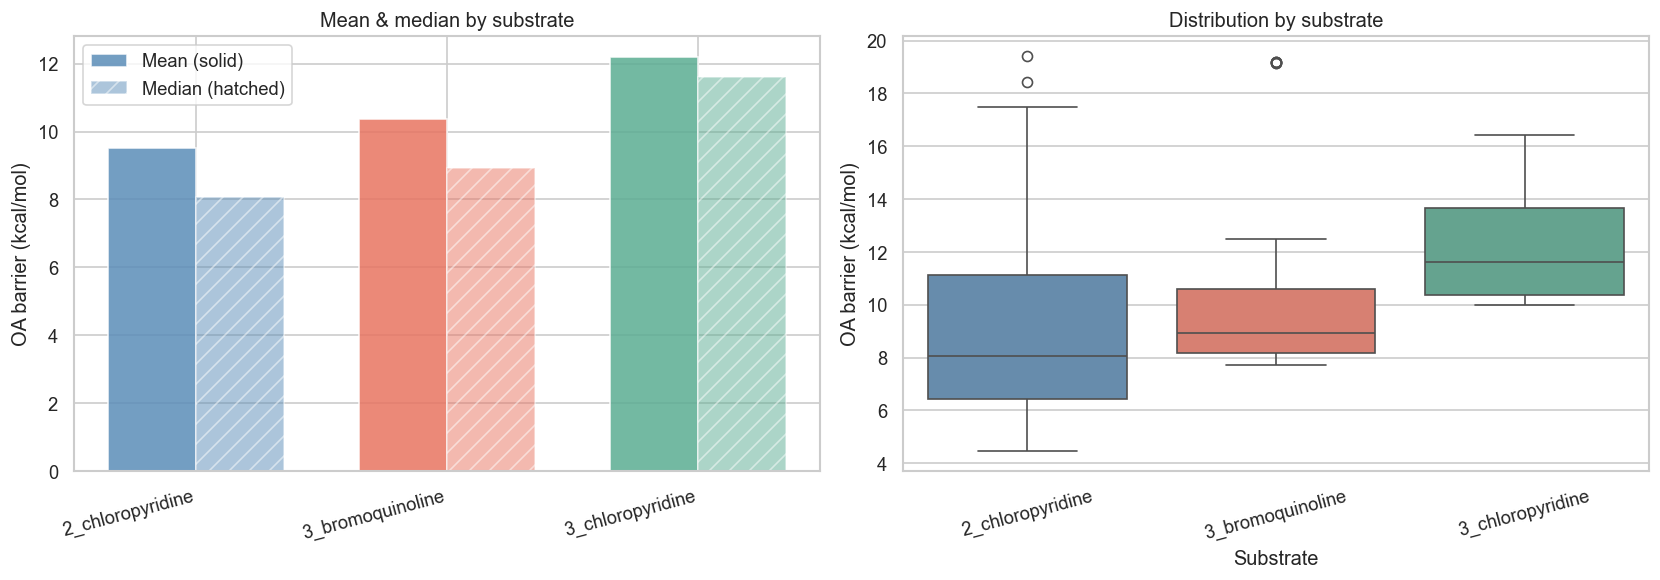

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

substrates = sub_stats.index.tolist()
x = np.arange(len(substrates))
w = 0.35
sub_colors = ['#5B8DB8', '#E87461', '#5BAD92']

axes[0].bar(x - w/2, sub_stats['mean'], width=w, label='Mean', color=sub_colors, alpha=0.85)
axes[0].bar(x + w/2, sub_stats['median'], width=w, label='Median', color=sub_colors, alpha=0.5, hatch='//')
axes[0].set_xticks(x)
axes[0].set_xticklabels(substrates, rotation=15, ha='right')
axes[0].set_ylabel('OA barrier (kcal/mol)')
axes[0].set_title('Mean & median by substrate')
axes[0].legend(['Mean (solid)', 'Median (hatched)'])

sns.boxplot(data=df, x='substrate', y=TARGET, palette=sub_colors, order=substrates, ax=axes[1])
axes[1].set_xlabel('Substrate')
axes[1].set_ylabel('OA barrier (kcal/mol)')
axes[1].set_title('Distribution by substrate')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

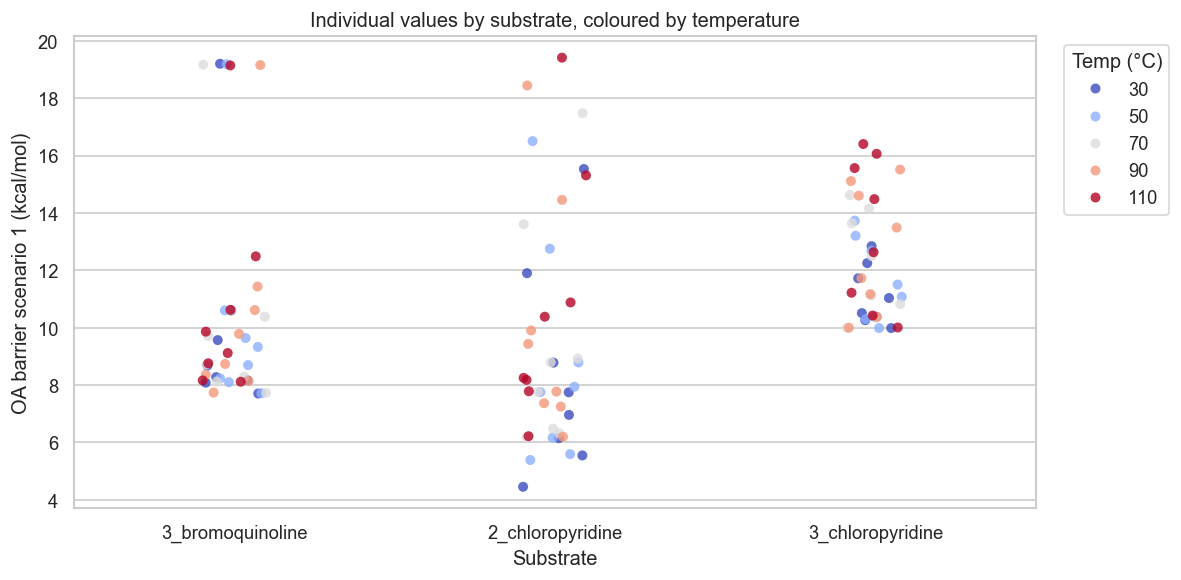

In [12]:
# Strip plot — individual data points by substrate, coloured by temperature
fig, ax = plt.subplots(figsize=(10, 5))
sns.stripplot(data=df, x='substrate', y=TARGET, hue='temp_C',
              palette='coolwarm', jitter=True, size=6, alpha=0.8, ax=ax)
ax.set_xlabel('Substrate')
ax.set_ylabel('OA barrier scenario 1 (kcal/mol)')
ax.set_title('Individual values by substrate, coloured by temperature')
ax.legend(title='Temp (°C)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Analysis by ligand

In [9]:
lig_stats = (
    df.groupby('ligand')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
    .sort_values('mean')
)
lig_stats

,mean,median,std,min,max,count
ligand,,,,,,
PPh3,8.653,8.142,2.120,5.547,12.632,15
PCy3,8.873,7.740,2.962,4.453,14.485,15
tBu3,9.007,9.711,2.154,6.148,11.220,15
Catacxium_A,9.317,8.795,0.660,8.680,10.384,15
AmPhos,9.573,10.341,1.329,7.747,10.623,15
XPhos,10.506,9.118,2.929,6.959,16.065,15
SPhos,12.546,12.684,2.115,8.278,15.568,15
RuPhos,17.093,17.479,2.240,12.845,19.418,15


C:\Users\livio\AppData\Local\Temp\ipykernel_87052\2721639638.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='ligand', x=TARGET, order=ligands,


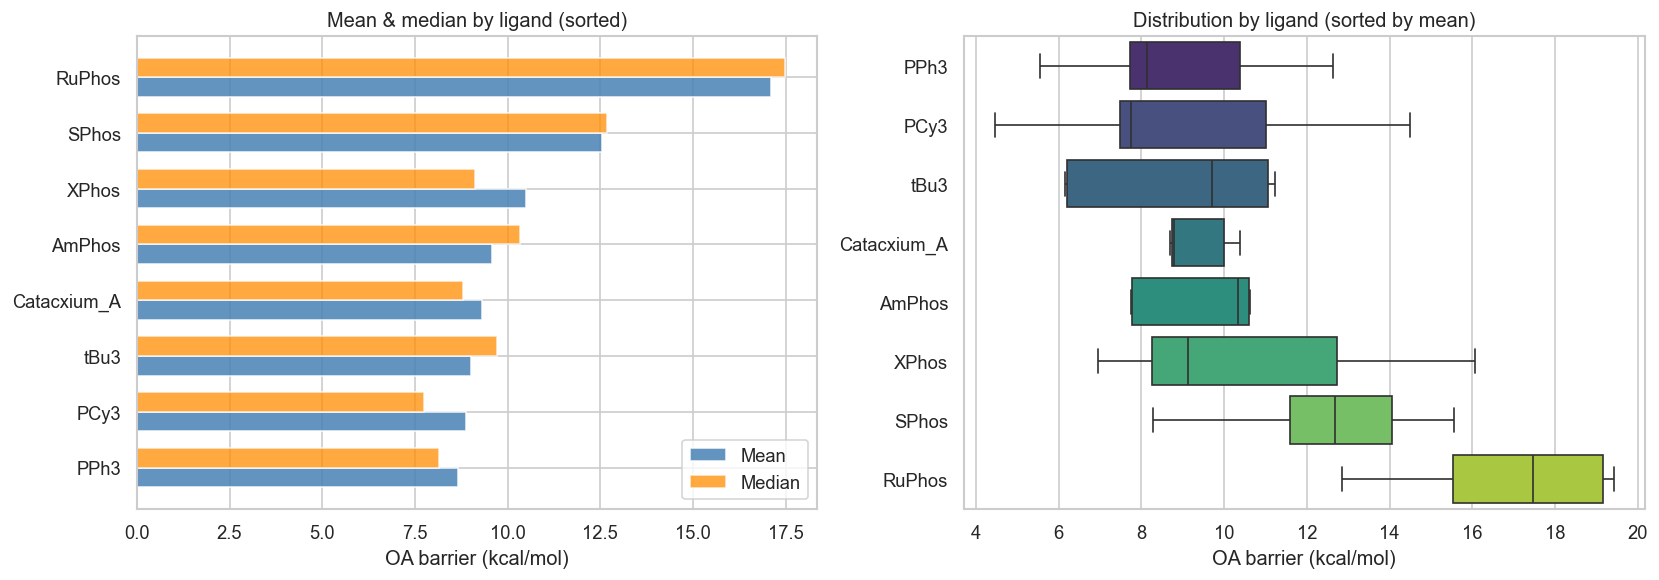

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ligands = lig_stats.index.tolist()
y = np.arange(len(ligands))
w = 0.35

# Horizontal bar chart sorted by mean
axes[0].barh(y - w/2, lig_stats['mean'], height=w, label='Mean', color='steelblue', alpha=0.85)
axes[0].barh(y + w/2, lig_stats['median'], height=w, label='Median', color='darkorange', alpha=0.75)
axes[0].set_yticks(y)
axes[0].set_yticklabels(ligands)
axes[0].set_xlabel('OA barrier (kcal/mol)')
axes[0].set_title('Mean & median by ligand (sorted)')
axes[0].legend()

# Box plot by ligand
sns.boxplot(data=df, y='ligand', x=TARGET, order=ligands,
            palette='viridis', orient='h', ax=axes[1])
axes[1].set_xlabel('OA barrier (kcal/mol)')
axes[1].set_ylabel('')
axes[1].set_title('Distribution by ligand (sorted by mean)')

plt.tight_layout()
plt.show()

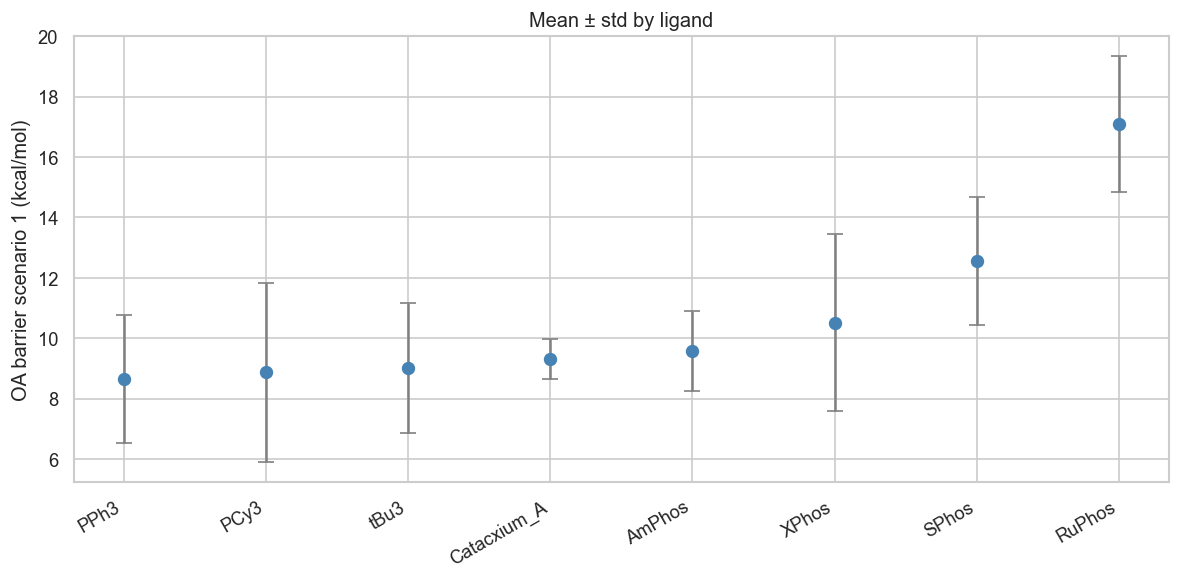

In [15]:
# Error bar plot: mean ± std per ligand
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    x=range(len(ligands)),
    y=lig_stats['mean'],
    yerr=lig_stats['std'],
    fmt='o', color='steelblue', ecolor='gray',
    elinewidth=1.5, capsize=5, markersize=7
)
ax.set_xticks(range(len(ligands)))
ax.set_xticklabels(ligands, rotation=30, ha='right')
ax.set_ylabel('OA barrier scenario 1 (kcal/mol)')
ax.set_title('Mean ± std by ligand')
plt.tight_layout()
plt.show()

## 6. Heatmap: ligand × substrate (mean OA barrier)

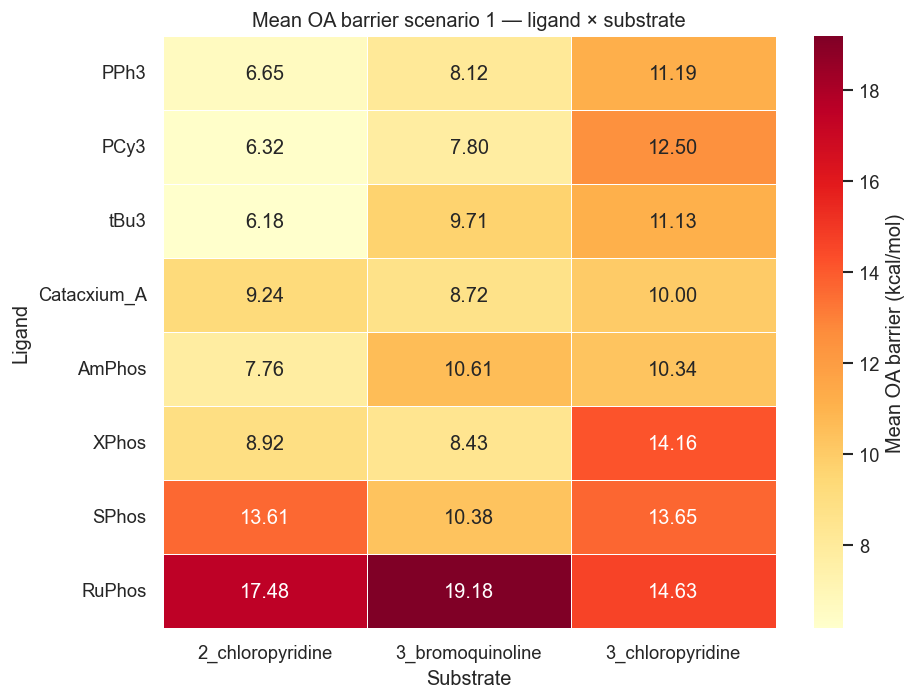

In [16]:
pivot_mean = df.pivot_table(values=TARGET, index='ligand', columns='substrate', aggfunc='mean')
pivot_mean = pivot_mean.loc[lig_stats.index]  # keep sorted by mean

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot_mean, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean OA barrier (kcal/mol)'}
)
ax.set_title('Mean OA barrier scenario 1 — ligand × substrate')
ax.set_xlabel('Substrate')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

### Heatmap at 90°C specifically

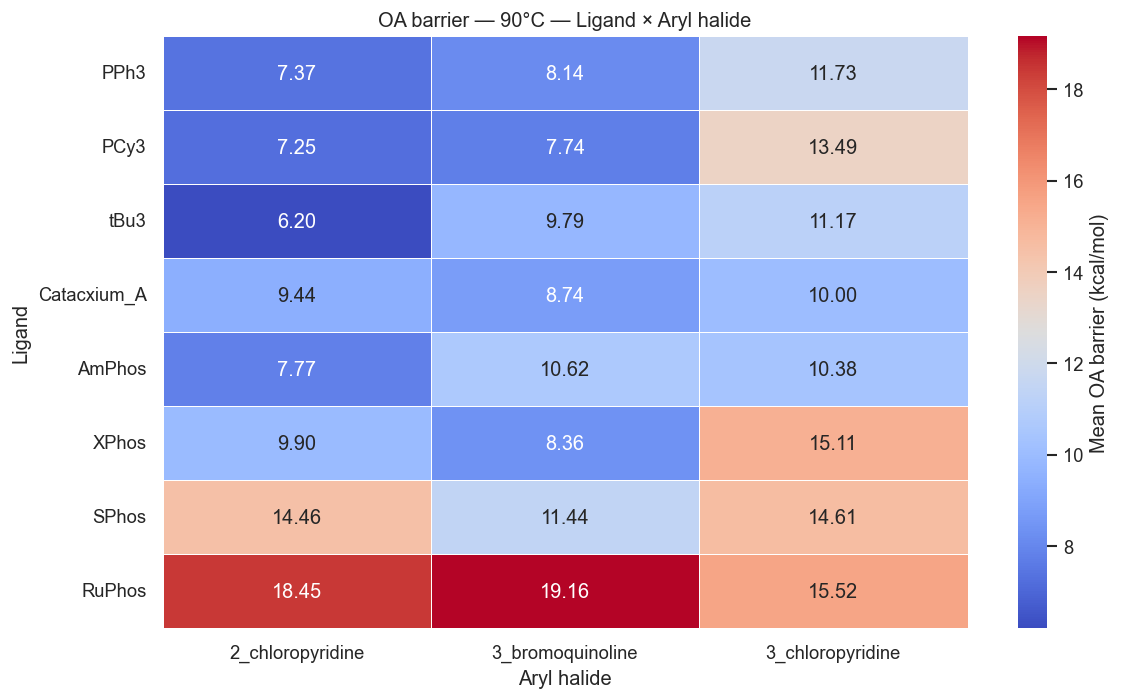

In [11]:
df_90 = df[df['temp_C'] == 90]
pivot_temp = df_90.pivot_table(values=TARGET, index='ligand', columns='substrate', aggfunc='mean')
pivot_temp = pivot_temp.loc[lig_stats.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot_temp, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean OA barrier (kcal/mol)'}
)
ax.set_title('OA barrier — 90°C — Ligand × Aryl halide')
ax.set_xlabel('Aryl halide')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

## 7. Heatmap: ligand × temperature (mean OA barrier)

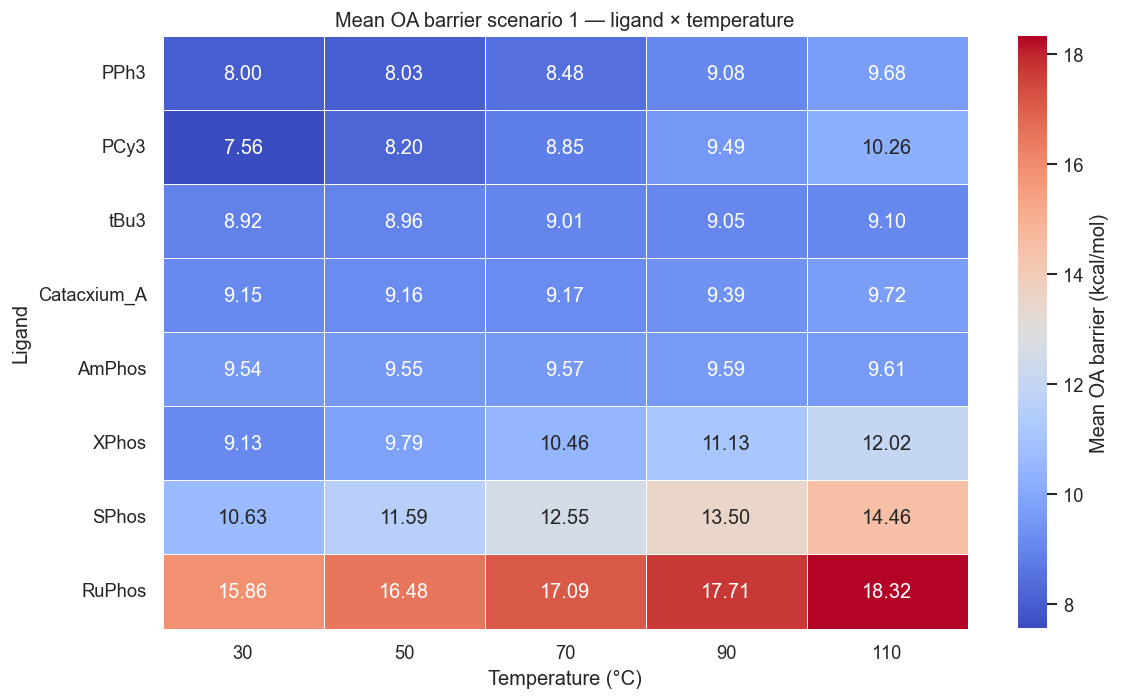

In [28]:
pivot_temp = df.pivot_table(values=TARGET, index='ligand', columns='temp_C', aggfunc='mean')
pivot_temp = pivot_temp.loc[lig_stats.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot_temp, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean OA barrier (kcal/mol)'}
)
ax.set_title('Mean OA barrier scenario 1 — ligand × temperature')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

## 8. Interaction: barrier vs temperature, per ligand

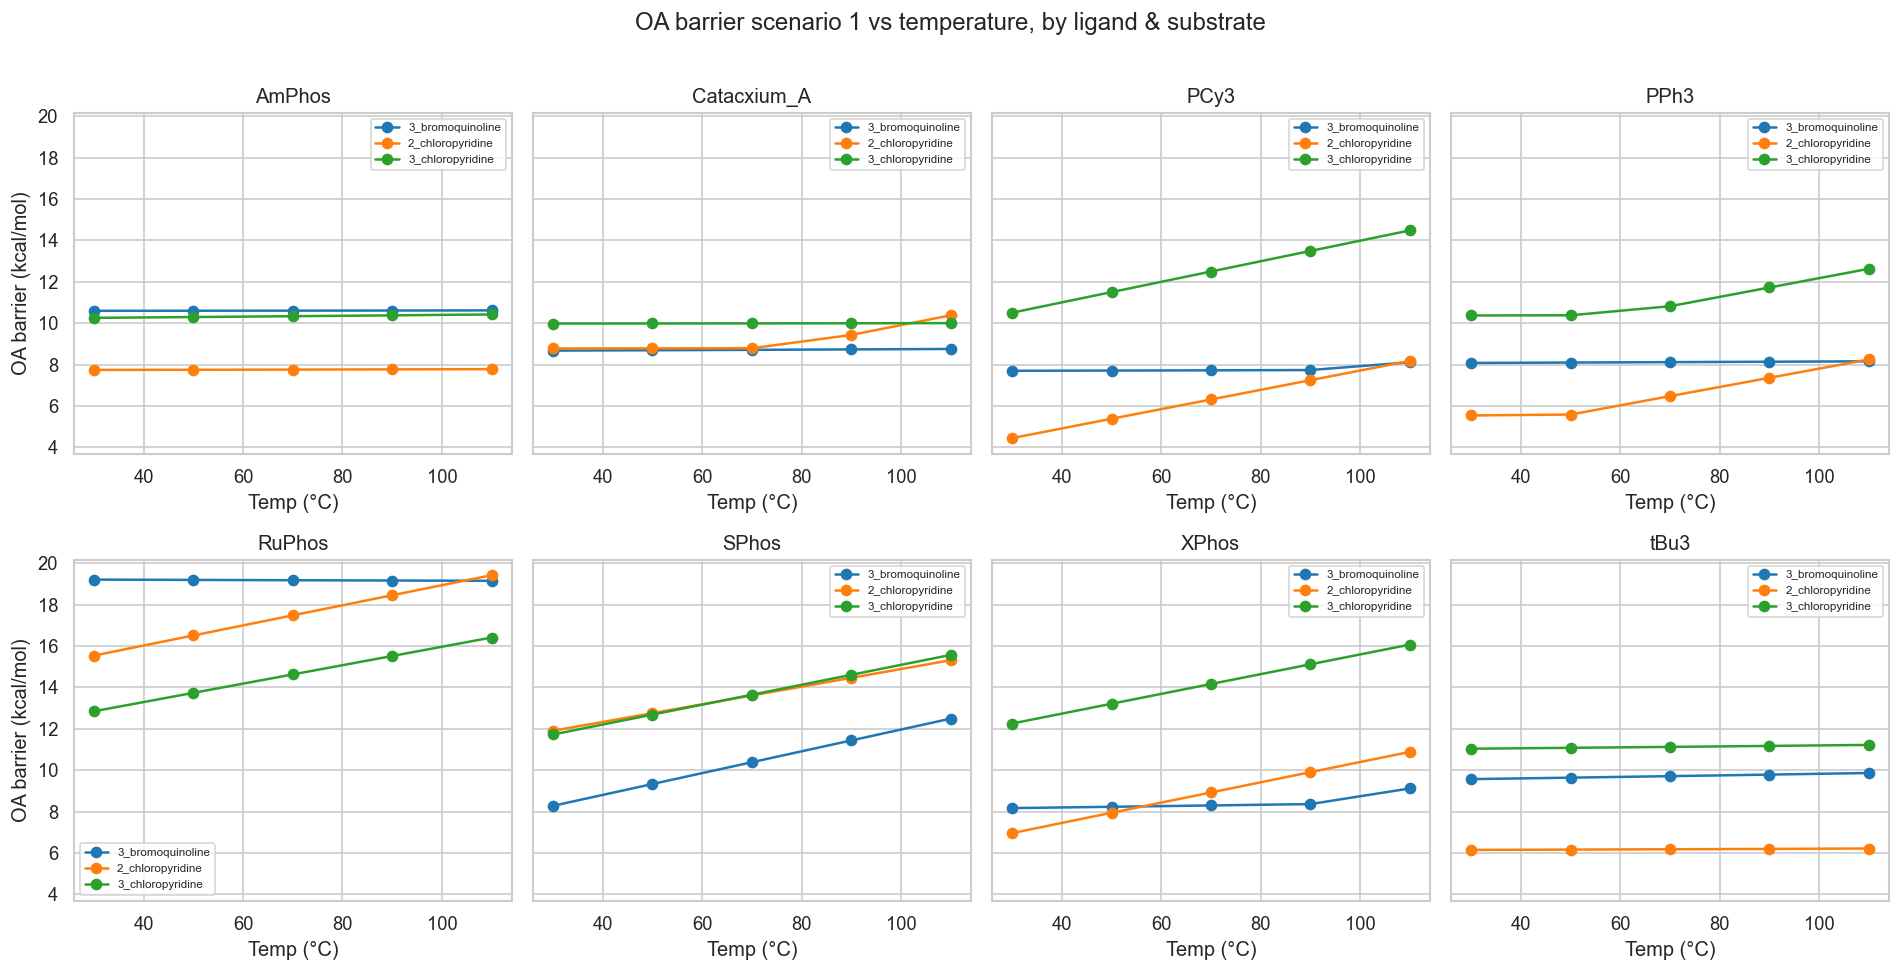

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()

palette = sns.color_palette('tab10', len(df['substrate'].unique()))

for i, lig in enumerate(sorted(df['ligand'].unique())):
    sub_df = df[df['ligand'] == lig]
    for j, sub in enumerate(df['substrate'].unique()):
        s = sub_df[sub_df['substrate'] == sub].sort_values('temp_C')
        axes[i].plot(s['temp_C'], s[TARGET], marker='o', label=sub, color=palette[j])
    axes[i].set_title(lig)
    axes[i].set_xlabel('Temp (°C)')
    if i % 4 == 0:
        axes[i].set_ylabel('OA barrier (kcal/mol)')
    axes[i].legend(fontsize=7)

plt.suptitle('OA barrier scenario 1 vs temperature, by ligand & substrate', y=1.01)
plt.tight_layout()
plt.show()

## 9. Summary statistics table

In [21]:
summary = (
    df.groupby(['ligand', 'substrate', 'temp_C'])[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(3)
    .reset_index()
)
summary.head(20)

,ligand,substrate,temp_C,mean,median,std,min,max
0,AmPhos,2_chloropyridine,30,7.747,7.747,NaN,7.747,7.747
1,AmPhos,2_chloropyridine,50,7.754,7.754,NaN,7.754,7.754
2,AmPhos,2_chloropyridine,70,7.763,7.763,NaN,7.763,7.763
3,AmPhos,2_chloropyridine,90,7.773,7.773,NaN,7.773,7.773
4,AmPhos,2_chloropyridine,110,7.785,7.785,NaN,7.785,7.785
5,AmPhos,3_bromoquinoline,30,10.603,10.603,NaN,10.603,10.603
6,AmPhos,3_bromoquinoline,50,10.606,10.606,NaN,10.606,10.606
7,AmPhos,3_bromoquinoline,70,10.610,10.610,NaN,10.610,10.610
8,AmPhos,3_bromoquinoline,90,10.616,10.616,NaN,10.616,10.616
9,AmPhos,3_bromoquinoline,110,10.623,10.623,NaN,10.623,10.623
